In [71]:
from datasets import load_dataset
import pandas as pd

# Load dataset
ds_level2 = load_dataset(
    "Quandela/Challenge_Swaptions",
    data_files="level-2_Missing_data_prediction/train_level2.csv",
    split="train",
)

# Convert to pandas
df = ds_level2.to_pandas()

print(df.shape)
print(df.head())
print(df.columns)

(489, 225)
         Date  Tenor : 1; Maturity : 0.0833333333333333  \
0  01/01/2050                                  0.028565   
1  02/01/2050                                  0.029334   
2  03/01/2050                                  0.028696   
3  05/01/2050                                  0.030854   
4  06/01/2050                                  0.030406   

   Tenor : 2; Maturity : 0.0833333333333333  \
0                                  0.038700   
1                                  0.039499   
2                                  0.038816   
3                                  0.041536   
4                                  0.041174   

   Tenor : 3; Maturity : 0.0833333333333333  \
0                                  0.040127   
1                                  0.040982   
2                                  0.040328   
3                                  0.043035   
4                                  0.042681   

   Tenor : 4; Maturity : 0.0833333333333333  \
0                    

In [72]:
import numpy as np

X = df[sorted_cols].replace(0, np.nan)

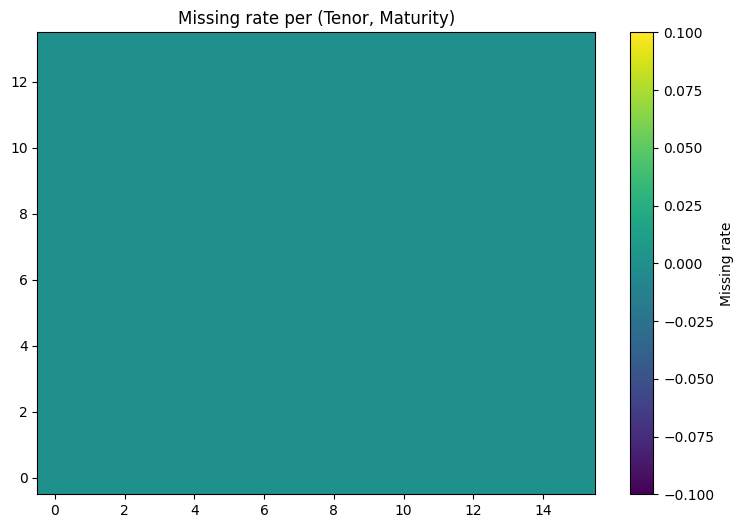

In [73]:
zero_rate = (df[sorted_cols] == 0).mean(axis=0)
ZR = zero_rate.to_numpy().reshape(len(tenors), len(maturities))

plt.figure(figsize=(9,6))
plt.imshow(ZR, aspect="auto", origin="lower")
plt.colorbar(label="Missing rate")
plt.title("Missing rate per (Tenor, Maturity)")
plt.show()

In [74]:
# Remove date column if present
surface_cols = [c for c in df.columns if c.lower() not in ["date", "timestamp"]]

print("Number of surface points:", len(surface_cols))
print(surface_cols[:10])

Number of surface points: 224
['Tenor : 1; Maturity : 0.0833333333333333', 'Tenor : 2; Maturity : 0.0833333333333333', 'Tenor : 3; Maturity : 0.0833333333333333', 'Tenor : 4; Maturity : 0.0833333333333333', 'Tenor : 5; Maturity : 0.0833333333333333', 'Tenor : 6; Maturity : 0.0833333333333333', 'Tenor : 7; Maturity : 0.0833333333333333', 'Tenor : 8; Maturity : 0.0833333333333333', 'Tenor : 9; Maturity : 0.0833333333333333', 'Tenor : 10; Maturity : 0.0833333333333333']


In [75]:
import re
import numpy as np
import pandas as pd

# surface_cols already defined
pattern = re.compile(r"Tenor\s*:\s*([0-9]+)\s*;\s*Maturity\s*:\s*([0-9]*\.?[0-9]+(?:e-?\d+)?)", re.IGNORECASE)

meta = []
bad = []
for c in surface_cols:
    m = pattern.search(c)
    if m:
        tenor = int(m.group(1))
        maturity = float(m.group(2))
        meta.append((c, tenor, maturity))
    else:
        bad.append(c)

print("Parsed:", len(meta), " / bad:", len(bad))
if bad:
    print("Example bad col:", bad[0])
    
meta_df = pd.DataFrame(meta, columns=["col", "tenor", "maturity"])
meta_df.head()

tenors = np.sort(meta_df["tenor"].unique())
maturities = np.sort(meta_df["maturity"].unique())

print("n_tenors:", len(tenors), "n_maturities:", len(maturities), "product:", len(tenors)*len(maturities))

# map (tenor, maturity) -> column name
tm_to_col = {(r.tenor, r.maturity): r.col for r in meta_df.itertuples(index=False)}

sorted_cols = []
missing_pairs = []
for t in tenors:
    for m in maturities:
        if (t, m) in tm_to_col:
            sorted_cols.append(tm_to_col[(t, m)])
        else:
            missing_pairs.append((t, m))

print("sorted_cols:", len(sorted_cols))
print("missing pairs:", len(missing_pairs))
if missing_pairs:
    print("First missing pair:", missing_pairs[0])

Parsed: 224  / bad: 0
n_tenors: 14 n_maturities: 16 product: 224
sorted_cols: 224
missing pairs: 0


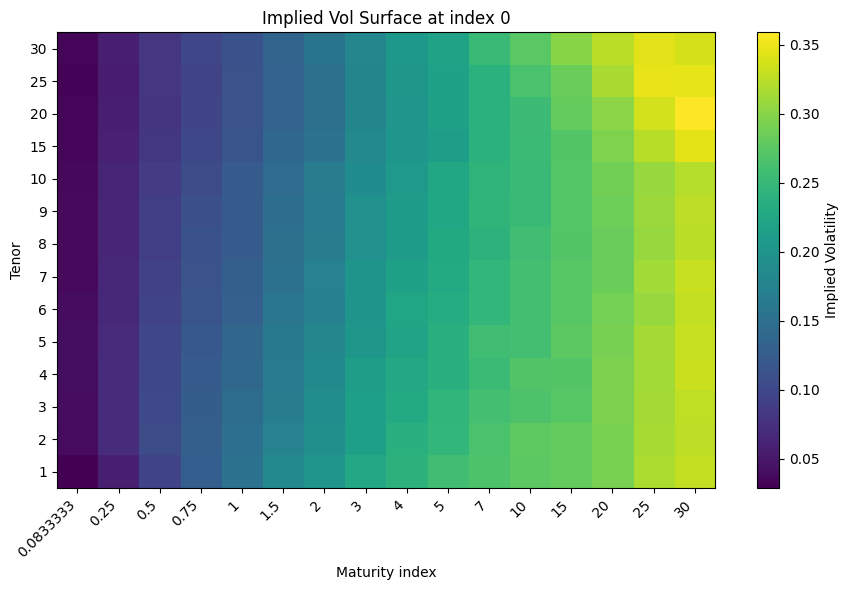

In [76]:
import matplotlib.pyplot as plt

k = 0  # time index / row in df

vals = df.loc[df.index[k], sorted_cols].to_numpy(dtype=float)
S = vals.reshape(len(tenors), len(maturities))

plt.figure(figsize=(9,6))
plt.imshow(S, aspect="auto", origin="lower")
plt.colorbar(label="Implied Volatility")
plt.title(f"Implied Vol Surface at index {k}")
plt.xlabel("Maturity index")
plt.ylabel("Tenor")
plt.yticks(range(len(tenors)), tenors)
plt.xticks(range(len(maturities)), [f"{x:g}" for x in maturities], rotation=45, ha="right")
plt.tight_layout()
plt.show()

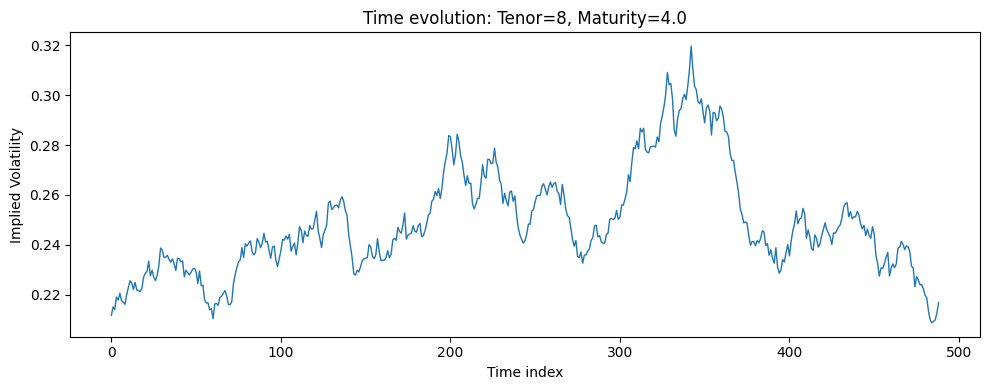

Column: Tenor : 8; Maturity : 4
Missing in this series: 0


In [77]:
t0 = tenors[len(tenors)//2]
m0 = maturities[len(maturities)//2]
col0 = tm_to_col[(t0, m0)]

plt.figure(figsize=(10,4))
plt.plot(df[col0].to_numpy(), linewidth=1)
plt.title(f"Time evolution: Tenor={t0}, Maturity={m0}")
plt.xlabel("Time index")
plt.ylabel("Implied Volatility")
plt.tight_layout()
plt.show()

print("Column:", col0)
print("Missing in this series:", int(df[col0].isna().sum()))

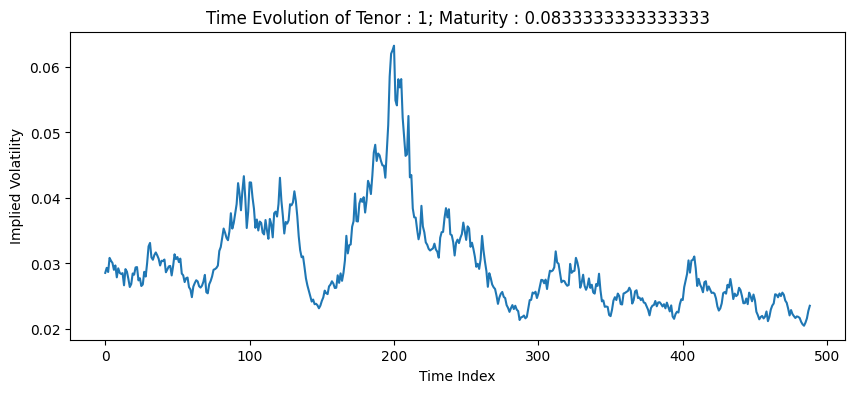

In [78]:
point = surface_cols[0]  # choose first point

plt.figure(figsize=(10,4))
plt.plot(df[point])
plt.title(f"Time Evolution of {point}")
plt.xlabel("Time Index")
plt.ylabel("Implied Volatility")
plt.show()

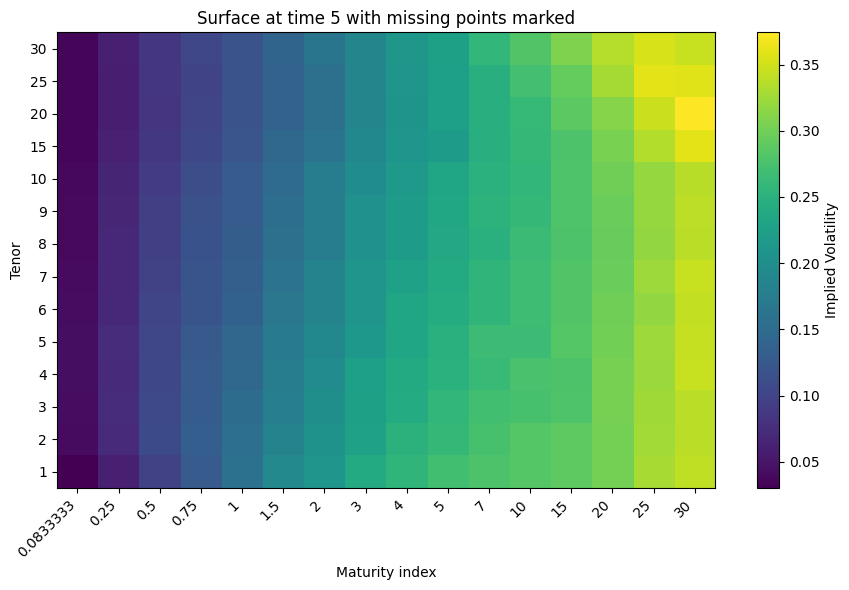

In [79]:
k = 5

vals = df.loc[df.index[k], sorted_cols].to_numpy(dtype=float)
S = vals.reshape(len(tenors), len(maturities))
missing = np.isnan(S)

plt.figure(figsize=(9,6))
plt.imshow(S, aspect="auto", origin="lower")
plt.colorbar(label="Implied Volatility")
ys, xs = np.where(missing)              # grid indices of missing cells
plt.scatter(xs, ys, marker="x")         # overlay X marks
plt.title(f"Surface at time {k} with missing points marked")
plt.xlabel("Maturity index")
plt.ylabel("Tenor")
plt.yticks(range(len(tenors)), tenors)
plt.xticks(range(len(maturities)), [f"{x:g}" for x in maturities], rotation=45, ha="right")
plt.tight_layout()
plt.show()

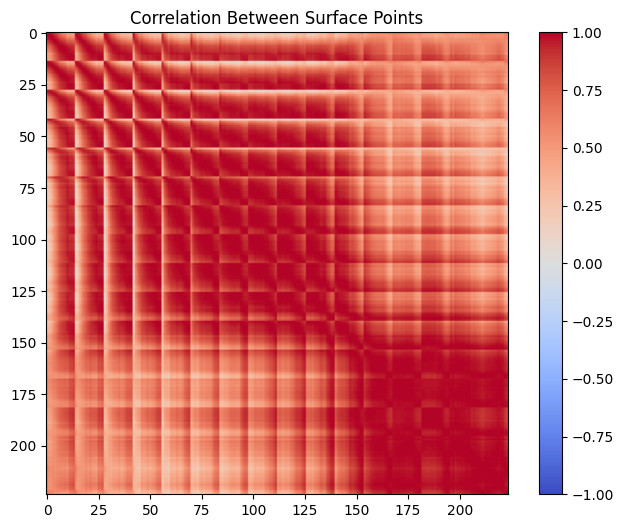

In [80]:
corr = df[surface_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.title("Correlation Between Surface Points")
plt.show()

In [81]:
k = 0
vals = df.loc[df.index[k], sorted_cols].to_numpy(dtype=float)
S = vals.reshape(len(tenors), len(maturities))
missing = np.isnan(S)

missing_pairs = [(tenors[i], maturities[j]) for i, j in zip(*np.where(missing))]
print("First 20 missing (tenor, maturity):", missing_pairs[:20])
print("Total missing:", len(missing_pairs))

First 20 missing (tenor, maturity): []
Total missing: 0


In [82]:
miss_rate = df[sorted_cols].isna().mean(axis=0)  # per point
top = miss_rate.sort_values(ascending=False).head(15)
print(top)

Tenor : 1; Maturity : 0.0833333333333333     0.0
Tenor : 1; Maturity : 0.25                   0.0
Tenor : 9; Maturity : 25                     0.0
Tenor : 9; Maturity : 30                     0.0
Tenor : 10; Maturity : 0.0833333333333333    0.0
Tenor : 10; Maturity : 0.25                  0.0
Tenor : 10; Maturity : 0.5                   0.0
Tenor : 10; Maturity : 0.75                  0.0
Tenor : 10; Maturity : 1                     0.0
Tenor : 10; Maturity : 1.5                   0.0
Tenor : 10; Maturity : 2                     0.0
Tenor : 10; Maturity : 3                     0.0
Tenor : 10; Maturity : 4                     0.0
Tenor : 10; Maturity : 5                     0.0
Tenor : 10; Maturity : 7                     0.0
dtype: float64


In [83]:
zero_count = (df[sorted_cols] == 0).sum().sum()
print("Total zero entries:", zero_count)

print("Zero ratio:",
      (df[sorted_cols] == 0).mean().mean())

Total zero entries: 0
Zero ratio: 0.0


#____________________________________________________________________________________________

In [99]:
import re

def norm_col(s: str) -> str:
    s = str(s)
    s = re.sub(r"\s+", " ", s.strip())  # collapse spaces
    s = s.replace(" ;", ";").replace("; ", "; ").replace(" : ", ": ")
    return s



In [100]:
import pandas as pd

template = pd.read_excel("/Users/alexquach/Downloads/test_template_new.xlsx")

print(df_template.shape)
print(df_template.head())
print(df_template.columns[:10])

(1, 226)
   Missing data  0.023603  0.03299  0.03585  0.03833  0.04  0.03948  0.03953  \
0  Missing data   0.02344  0.03254  0.03549  0.03812   NaN  0.03953  0.03977   

   0.03953.1  0.03989  ...  0.33147  0.33561  0.32972  0.33364  0.33296  \
0    0.03988  0.04034  ...  0.33931  0.34369  0.33781  0.34195  0.34138   

     0.353   0.3653  0.34347  0.33181  2051-04-08 00:00:00  
0  0.36149  0.37428  0.34943  0.33645           09/20/2051  

[1 rows x 226 columns]
Index(['Missing data',      0.0236028,        0.03299,        0.03585,
              0.03833,           0.04,        0.03948,        0.03953,
          '0.03953.1',        0.03989],
      dtype='object')


In [101]:
# Make sure we only use the surface columns that exist in BOTH
common_cols = [c for c in sorted_cols if c in template.columns and c in df.columns]
print("Common surface cols:", len(common_cols))

# Missing mask inferred from template NaNs (True = missing)
mask_missing = template[common_cols].isna().to_numpy()
mask_missing = template[common_cols].isna().values.astype(bool)

print("Missing ratio in template:", mask_missing.mean())

Common surface cols: 224
Missing ratio in template: 0.022321428571428572


In [102]:
print(mask_missing.dtype)
print(mask_missing.shape)

bool
(2, 224)


In [103]:
df_norm = df.copy()
df_norm.columns = [norm_col(c) for c in df_norm.columns]

template_norm = template.copy()
template_norm.columns = [norm_col(c) for c in template_norm.columns]

sorted_cols_norm = [norm_col(c) for c in sorted_cols]

common_cols = [c for c in sorted_cols_norm if c in template_norm.columns and c in df_norm.columns]
print("Common cols after normalization:", len(common_cols))

Common cols after normalization: 224


In [110]:
import re
import numpy as np
import pandas as pd

def canon_col(s: str) -> str:
    s = str(s).strip()
    s = re.sub(r"\s*:\s*", ": ", s)   # "Tenor : 1" -> "Tenor: 1"
    s = re.sub(r"\s*;\s*", "; ", s)   # normalize ";"
    s = re.sub(r"\s+", " ", s)        # collapse spaces
    return s

df2 = df.copy()
df2.columns = [canon_col(c) for c in df2.columns]

template2 = template.copy()
template2.columns = [canon_col(c) for c in template2.columns]

sorted_cols2 = [canon_col(c) for c in sorted_cols]
common_cols2 = [c for c in sorted_cols2 if c in df2.columns and c in template2.columns]

print("Common cols:", len(common_cols2))
print("Example:", common_cols2[:3])

Common cols: 224
Example: ['Tenor: 1; Maturity: 0.0833333333333333', 'Tenor: 1; Maturity: 0.25', 'Tenor: 1; Maturity: 0.5']


In [112]:
T = min(len(df2), len(template2))

df_slice = df2.loc[df2.index[:T], common_cols2].copy()
template_slice = template2.loc[template2.index[:T], common_cols2]

mask_missing = template_slice.isna()
df_slice[mask_missing] = np.nan

df_masked = df_slice

print("df_masked shape:", df_masked.shape)
print("Total missing:", int(df_masked.isna().sum().sum()))
print("Missing ratio:", float(df_masked.isna().mean().mean()))

df_masked shape: (2, 224)
Total missing: 10
Missing ratio: 0.022321428571428572


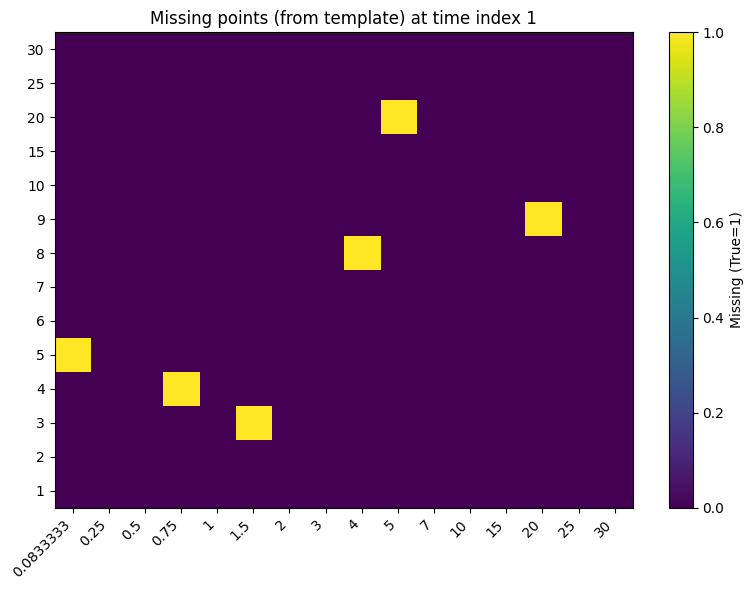

In [117]:
import matplotlib.pyplot as plt

k = 1
vals = df_masked.loc[df_masked.index[k], common_cols].to_numpy(dtype=float)

S = vals.reshape(len(tenors), len(maturities))
missing = np.isnan(S)

plt.figure(figsize=(8,6))
plt.imshow(missing, aspect="auto", origin="lower")
plt.title(f"Missing points (from template) at time index {k}")
plt.colorbar(label="Missing (True=1)")
plt.yticks(range(len(tenors)), tenors)
plt.xticks(range(len(maturities)), [f"{x:g}" for x in maturities], rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [114]:
print("len(sorted_cols):", len(sorted_cols))
print("len(common_cols):", len(common_cols))
print("df.shape:", df.shape)
print("template.shape:", template.shape)

print("df_masked shape (if exists):", df_masked.shape)
print("first 5 common cols:", common_cols[:5])

len(sorted_cols): 224
len(common_cols): 224
df.shape: (489, 225)
template.shape: (2, 226)
df_masked shape (if exists): (2, 224)
first 5 common cols: ['Tenor: 1; Maturity: 0.0833333333333333', 'Tenor: 1; Maturity: 0.25', 'Tenor: 1; Maturity: 0.5', 'Tenor: 1; Maturity: 0.75', 'Tenor: 1; Maturity: 1']


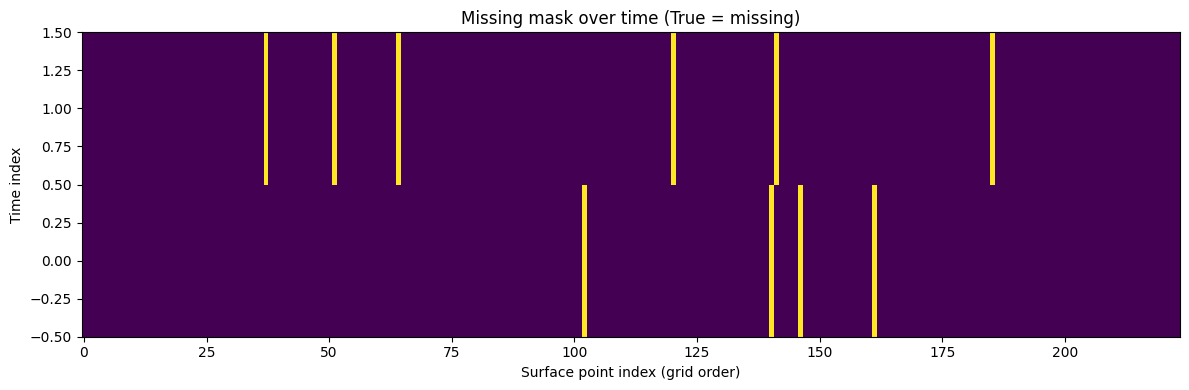

Total missing: 10
Missing ratio: 0.022321428571428572


In [118]:
import numpy as np
import matplotlib.pyplot as plt

mask = df_masked.isna().to_numpy()  # shape (T, 224)

plt.figure(figsize=(12,4))
plt.imshow(mask, aspect="auto", origin="lower")
plt.title("Missing mask over time (True = missing)")
plt.xlabel("Surface point index (grid order)")
plt.ylabel("Time index")
plt.tight_layout()
plt.show()

print("Total missing:", int(mask.sum()))
print("Missing ratio:", float(mask.mean()))

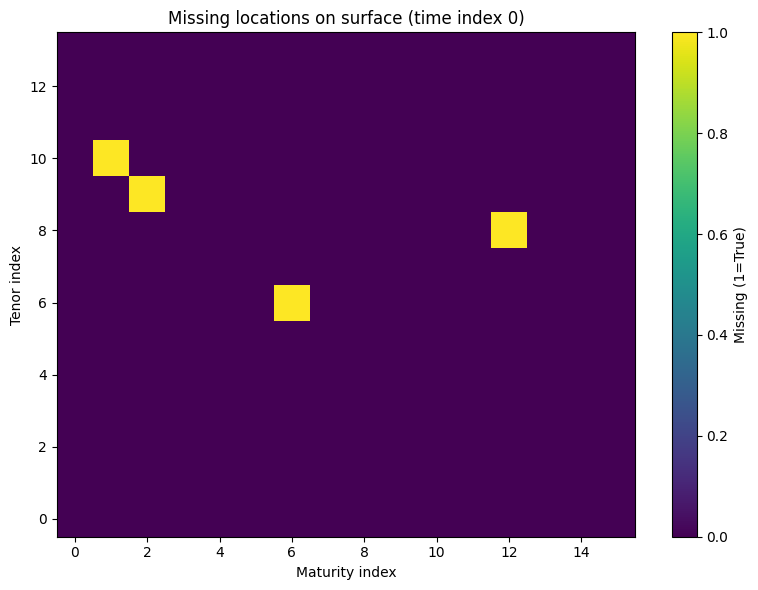

Missing count at k: 4


In [119]:
k = 0  # try a few values: 0, 10, 100...

vals = df_masked.iloc[k].to_numpy(dtype=float)
S = vals.reshape(14, 16)
missing = np.isnan(S)

plt.figure(figsize=(8,6))
plt.imshow(missing, aspect="auto", origin="lower")
plt.colorbar(label="Missing (1=True)")
plt.title(f"Missing locations on surface (time index {k})")
plt.xlabel("Maturity index")
plt.ylabel("Tenor index")
plt.tight_layout()
plt.show()

print("Missing count at k:", int(missing.sum()))

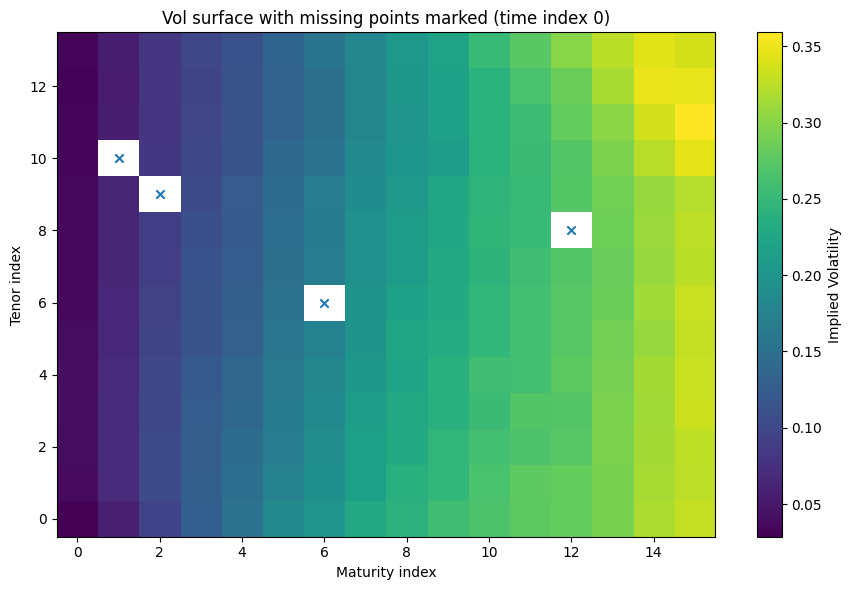

In [120]:
plt.figure(figsize=(9,6))
plt.imshow(S, aspect="auto", origin="lower")
plt.colorbar(label="Implied Volatility")

ys, xs = np.where(missing)
plt.scatter(xs, ys, marker="x")  # X marks missing

plt.title(f"Vol surface with missing points marked (time index {k})")
plt.xlabel("Maturity index")
plt.ylabel("Tenor index")
plt.tight_layout()
plt.show()

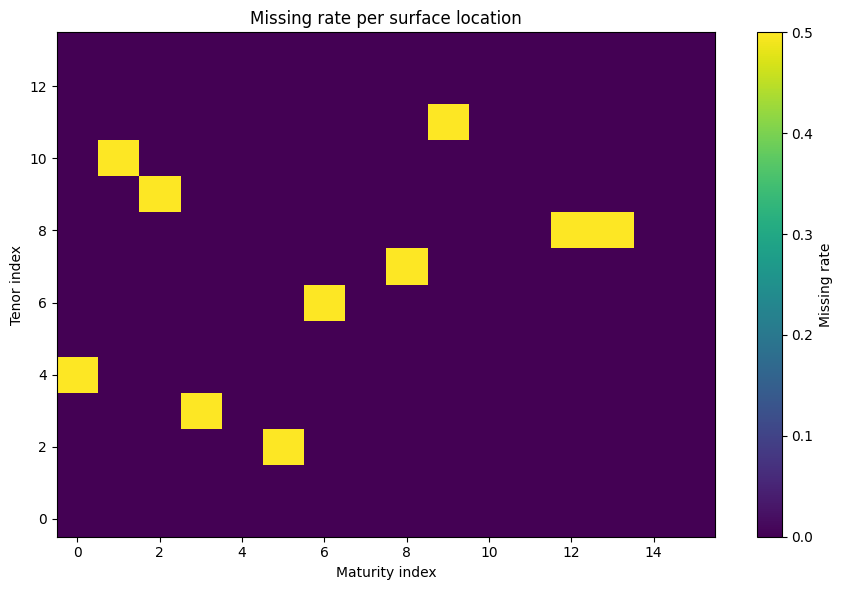

In [ ]:
miss_rate = df_masked.isna().mean(axis=0).to_numpy().reshape(14, 16)

plt.figure(figsize=(9,6))
plt.imshow(miss_rate, aspect="auto", origin="lower")
plt.colorbar(label="Missing rate")
plt.title("Missing rate per surface location")
plt.xlabel("Maturity index")
plt.ylabel("Tenor index")
plt.tight_layout()
plt.show()